# IMPORT LIBRARIES

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from matplotlib.dates import DateFormatter
from scipy.optimize import minimize # USE IN THE MODEL CALIBRATION

from google.colab import files
import zipfile
import os

#Analysis

### Here, we use the IS and Sigma values obtained and saved from the Stochastic model simulation for all diffusions

In [ ]:
IS_Pn = [
    2.3480, 2.1339, 2.1671, 13.4379, 4.8357, 4.6014, 2.4414, 2.9600,
    2.4568, 3.8548, 1.2497, 1.4864, 1.0887, 1.8236, 1.1104, 8.5638,
    8.1162, 5.3716, 6.8734, 3.1574, 3.5102, 4.7447, 2.7784, 2.8815,
    3.3361, 3.2079, 2.3310, 1.1907, 2.5149, 1.9057, 1.9557, 1.9122,
    2.1656, 2.2143, 2.0591, 1.2695, 1.8554, 1.6974, 1.6850, 2.7853,
    2.7791, 2.9233, 2.7653, 2.7447, 2.2372, 1.6645, 3.1434, 1.5933,
    2.5728, 2.8906, 2.1265, 2.0512, 3.9282, 3.2836, 1.7169, 2.1121,
    1.0023, 3.1456, 3.1242, 3.8450, 3.7595, 1.4745, 2.3552, 1.2051,
    1.1211, 1.5475, 1.3012, 0.9890, 0.4344, 0.9737, 1.2015, 0.7985,
    1.3058, 1.2520, 2.0103, 1.6768, 2.1819, 2.4140, 0.6680, 2.3201,
    1.9230, 1.4955, 1.3883, 2.3917, 4.2231, 3.5827, 1.8453, 1.7652,
    0.6349, 2.2390, 1.7373, 1.5501, 1.0713, 1.8291, 0.7191, 2.5507,
    2.1722, 1.4257, 1.4765, 0.9093, 0.6287, 0.6620, 0.5134, 0.3014,
    0.4544, 2.6316, 1.6219, 2.3402, 2.9332, 1.6319, 2.5686, 2.0804,
    2.4194, 2.6075, 1.6867, 2.1054, 1.1335, 1.1961, 2.5069, 1.5718,
    2.7803, 2.3606, 1.5902, 2.3043, 2.2759, 1.6818, 1.5890, 0.8103,
    2.8668, 1.0268, 1.0821, 0.9263, 0.7535, 0.7080, 2.7316, 2.8383,
    0.9894, 0.8091, 1.1135, 0.7591, 1.4100, 1.1654, 1.5416, 1.4760,
    1.2348, 2.3223, 1.9253, 1.6159, 3.6435, 2.7097, 2.4587, 1.6310,
    1.5087, 1.9857, 3.9779, 2.8348, 2.2873, 2.0791, 1.7103, 1.8832,
    2.3537, 1.8146, 1.9064, 1.4537, 1.8374, 1.8322, 2.1778, 2.0027,
    2.2865, 2.3148, 1.7267, 2.5866, 2.0074, 4.4739, 3.1173, 2.2990,
    3.7334, 2.6319, 2.5444, 2.9146, 3.2533, 3.1632, 3.2767, 3.2142,
    3.2842, 4.1583, 2.2651, 6.9859, 4.2865, 4.1992, 4.0834, 4.3603,
    2.6317, 2.9492, 2.6892, 3.8081, 4.8230, 3.5087, 2.7882, 2.6251,
    3.8290, 3.1895, 3.8189, 5.3545, 2.9661, 2.6514, 2.2067, 3.0197,
    2.2054, 1.9591, 1.9316, 2.6731, 1.9406, 1.8353, 1.8487, 1.7280,
    2.1473, 2.4989, 1.8407, 2.6443, 2.4795, 1.9267, 4.5008, 2.8808,
    2.2781, 2.2907, 6.5786, 2.3011, 2.6178, 2.1526, 2.7028, 2.2258,
    2.0655, 3.8296, 2.2646, 2.1746, 2.8726, 2.9205, 2.7715, 2.7428,
    2.5505, 2.6194, 11.6362, 6.5291, 3.0570, 2.2562, 3.1470, 2.8557,
    2.0804, 1.7149, 2.9558, 4.7922, 3.7433, 2.2473, 3.9057, 2.2067,
    2.3598, 2.2252, 4.0539, 2.2017, 1.0910, 2.3822, 1.9935, 1.6746,
    0.9221, 1.2736, 1.6559, 1.1105, 1.7669, 1.3519, 4.2281, 2.8762,
    2.2026, 2.2152, 2.9769, 1.6066, 1.2763, 2.5296, 2.0229, 1.8125,
    1.9151, 2.3169, 2.0609, 1.8433, 1.9426, 2.0568, 2.2427, 1.7535,
    1.3841, 2.0517, 1.3283, 1.4325, 1.3503, 1.2080, 1.0703, 0.7382,
    1.4791, 1.4203, 1.8742, 1.6648, 1.0974, 1.0157, 1.4391, 1.6979,
    1.3938, 0.7927, 2.3458, 1.7837, 1.7173, 1.9720, 1.7001, 2.0725,
    1.7221, 1.6736, 1.7403, 1.8727, 1.4250, 1.3639, 1.4698, 1.9022,
    0.9034, 2.6165, 1.4955, 2.7678, 2.4028, 2.4177, 2.8030, 3.2850,
    2.1737, 2.1098, 7.6758, 8.0697, 2.3317, 8.9408, 7.2291, 5.1848,
    3.5865, 5.2055, 5.4214, 10.2994, 6.8629, 6.4506, 3.0394, 2.0696,
    1.7408, 10.2630, 8.4766, 4.3998, 9.3249, 8.1108, 5.7903, 4.9706,
    12.3625, 2.5114, 4.3350, 3.4823, 2.3496, 2.0531, 2.0915, 2.1886,
    2.8115, 2.9538, 2.0520, 1.7650, 1.5426, 1.4139, 1.1351, 6.5461,
    3.2970, 2.6009, 2.9349, 2.3221, 2.6727, 2.4637, 3.0840, 3.2946,
    2.5777, 0.8661, 9.6229, 9.1314, 2.9161, 5.5604, 9.3124, 10.2544,
    4.7310, 2.9814, 2.9568, 2.9373, 4.7868, 4.0656, 3.5127, 3.1601,
    2.3823, 2.4792, 3.0431, 2.5561, 2.5170, 2.6233, 2.0277, 2.3927,
    2.1898, 2.0824, 2.6204, 1.6215, 1.7467, 6.5748, 4.1542, 4.0540,
    3.7691, 4.9983, 1.5839, 1.6859, 3.4370, 6.6076, 8.7213, 2.6367,
    1.6738, 1.6307, 4.3027, 3.0223, 5.2524, 3.7584, 3.8030, 3.5428,
    2.7280, 2.3139, 2.5682, 2.2105, 1.8759, 1.5786, 7.9617, 2.8167,
    3.5058, 3.2062, 2.8192, 1.9803, 2.0086, 2.1306, 1.6133, 1.4920,
    2.2303, 7.0095, 4.6355, 4.8999, 6.5191, 9.5589, 4.6098, 3.1676,
    3.3009, 7.6931, 3.6965, 1.9583, 2.4028, 4.6189, 3.4445, 4.3548,
    1.6954, 2.6692, 1.2499, 2.4757, 2.7640, 1.9934, 1.9952, 6.4611,
    13.5146, 13.0177, 14.4634, 7.2937, 6.9182, 7.9832, 2.8759, 2.3920,
    6.0024, 3.6951, 11.6361, 1.4734, 6.1908, 6.3591, 2.2953, 1.5694,
    2.2127, 0.4507, 2.1871, 3.1025, 4.3572, 4.4883, 6.9912, 3.0093,
    6.0956, 3.1817, 2.7132, 2.8874, 9.2568, 8.1664, 7.3865, 11.2601,
    10.9813, 3.5418, 3.1686, 11.4220, 6.5878, 7.7194, 4.4873, 3.1980,
    3.5383, 2.1470, 1.0953, 3.3295, 2.8093, 6.5864, 2.0616, 3.0567,
    1.2654, 2.5781, 1.9410, 4.1101, 3.6539, 2.4766, 3.5486, 2.8315,
    5.6753, 3.4057, 5.8265, 5.7221, 10.4344, 11.8419
]

sigma_Pn = [
0.1612, 0.1299, 0.1509, 0.2986, 0.1009, 0.0878, 0.0964, 0.1042, 0.0814, 0.1366,
0.0642, 0.0787, 0.0486, 0.1580, 0.0218, 0.2838, 0.2608, 0.1793, 0.2238, 0.0952,
0.0996, 0.1603, 0.1694, 0.2236, 0.1645, 0.0870, 0.1204, 0.0630, 0.1709, 0.1178,
0.0932, 0.0398, 0.1315, 0.1630, 0.1351, 0.0361, 0.1135, 0.1019, 0.1103, 0.2023,
0.1977, 0.1777, 0.1976, 0.1503, 0.0888, 0.0450, 0.1739, 0.0543, 0.1003, 0.1777,
0.0953, 0.0662, 0.2067, 0.1372, 0.0630, 0.1201, 0.0473, 0.0633, 0.1254, 0.2801,
0.2142, 0.0174, 0.0309, 0.0108, 0.0042, 0.0695, 0.0457, 0.0320, 0.0078, 0.0499,
0.0647, 0.0425, 0.0898, 0.0149, 0.0755, 0.0129, 0.0760, 0.0524, 0.0194, 0.0670,
0.0449, 0.0810, 0.0668, 0.0496, 0.1011, 0.0906, 0.1147, 0.0515, 0.0219, 0.1303,
0.0854, 0.0553, 0.0530, 0.0944, 0.0165, 0.1385, 0.0228, 0.0865, 0.0973, 0.0436,
0.0232, 0.0191, 0.0140, 0.0065, 0.0105, 0.1185, 0.0118, 0.1229, 0.1233, 0.0646,
0.0560, 0.0667, 0.0780, 0.0999, 0.0523, 0.1242, 0.0393, 0.0478, 0.1547, 0.0782,
0.1575, 0.0864, 0.0581, 0.1126, 0.1072, 0.0684, 0.0558, 0.0249, 0.1832, 0.0044,
0.0060, 0.0389, 0.0176, 0.0243, 0.1185, 0.1506, 0.0259, 0.0411, 0.0254, 0.0160,
0.0575, 0.0378, 0.0804, 0.1120, 0.0582, 0.1183, 0.0993, 0.0703, 0.1148, 0.1470,
0.1247, 0.0480, 0.0816, 0.0851, 0.1883, 0.1258, 0.0903, 0.0799, 0.0645, 0.1056,
0.1667, 0.1356, 0.1045, 0.0784, 0.1367, 0.1060, 0.0883, 0.0795, 0.0771, 0.0970,
0.0880, 0.1504, 0.0788, 0.1615, 0.1234, 0.0724, 0.1259, 0.0945, 0.0641, 0.0888,
0.1059, 0.0992, 0.1065, 0.1192, 0.0932, 0.1091, 0.0627, 0.1910, 0.1124, 0.1945,
0.1931, 0.1734, 0.0730, 0.0673, 0.0556, 0.1154, 0.1837, 0.0933, 0.0650, 0.0600,
0.1063, 0.1325, 0.1425, 0.2326, 0.0926, 0.0874, 0.0866, 0.0831, 0.1687, 0.1496,
0.1424, 0.2121, 0.1563, 0.1524, 0.1463, 0.1196, 0.1625, 0.1190, 0.1124, 0.0921,
0.1614, 0.1202, 0.1803, 0.1110, 0.1316, 0.1400, 0.1156, 0.0970, 0.0926, 0.0913,
0.1202, 0.1158, 0.1316, 0.1013, 0.1162, 0.1052, 0.1242, 0.1472, 0.1455, 0.1345,
0.1911, 0.1689, 0.5322, 0.2451, 0.0859, 0.0690, 0.0844, 0.0944, 0.0625, 0.0753,
0.0816, 0.0959, 0.1041, 0.0835, 0.0611, 0.0821, 0.0773, 0.0748, 0.1070, 0.0879,
0.0624, 0.0938, 0.1081, 0.1398, 0.0180, 0.0634, 0.0775, 0.0468, 0.1482, 0.1032,
0.1356, 0.1032, 0.0926, 0.1216, 0.1763, 0.0418, 0.0591, 0.0764, 0.0788, 0.1256,
0.1559, 0.0860, 0.0817, 0.0847, 0.0801, 0.1259, 0.1316, 0.0696, 0.0787, 0.0915,
0.0470, 0.0742, 0.0626, 0.0805, 0.0477, 0.0304, 0.0984, 0.0852, 0.1563, 0.1342,
0.0531, 0.0876, 0.1204, 0.1366, 0.1179, 0.0311, 0.1157, 0.0734, 0.0846, 0.1038,
0.0877, 0.1644, 0.1418, 0.0943, 0.1020, 0.1150, 0.0944, 0.0877, 0.1402, 0.1758,
0.0255, 0.2583, 0.1201, 0.2126, 0.1343, 0.1782, 0.2526, 0.3390, 0.1088, 0.1202,
0.0591, 0.1835, 0.1798, 0.1380, 0.1814, 0.1955, 0.2489, 0.2200, 0.1334, 0.1849,
0.1497, 0.2274, 0.2159, 0.1472, 0.1715, 0.1689, 0.1295, 0.1757, 0.5359, 0.2427,
0.1901, 0.2155, 0.3507, 0.0813, 0.1818, 0.1822, 0.1213, 0.0791, 0.0906, 0.1052,
0.1440, 0.1580, 0.1040, 0.1121, 0.0990, 0.1024, 0.0521, 0.1278, 0.1237, 0.0720,
0.1172, 0.0851, 0.0654, 0.1416, 0.1745, 0.1611, 0.1319, 0.0288, 0.2603, 0.2083,
0.0916, 0.1895, 0.1344, 0.2342, 0.1433, 0.1278, 0.1872, 0.1520, 0.1465, 0.1195,
0.1220, 0.1129, 0.1482, 0.0953, 0.1424, 0.1131, 0.1221, 0.1259, 0.1021, 0.1103,
0.0991, 0.0787, 0.0931, 0.0637, 0.0572, 0.0842, 0.1002, 0.0773, 0.1093, 0.2342,
0.0341, 0.0416, 0.1294, 0.2804, 0.1670, 0.1132, 0.0412, 0.0210, 0.0774, 0.1240,
0.1645, 0.1604, 0.1368, 0.1690, 0.1194, 0.1129, 0.1521, 0.1011, 0.0830, 0.0621,
0.2444, 0.1521, 0.1459, 0.1208, 0.0973, 0.0815, 0.1180, 0.0686, 0.0497, 0.0389,
0.0558, 0.1846, 0.0977, 0.1806, 0.3249, 0.2571, 0.1718, 0.1903, 0.2039, 0.2849,
0.1149, 0.0699, 0.1412, 0.2697, 0.1365, 0.2651, 0.0886, 0.0988, 0.0843, 0.1555,
0.1877, 0.1637, 0.1317, 0.1943, 0.1342, 0.3464, 0.2777, 0.1255, 0.2021, 0.1377,
0.0966, 0.0987, 0.1173, 0.0757, 0.2265, 0.0295, 0.2347, 0.1996, 0.0880, 0.1104,
0.1470, 0.0146, 0.0920, 0.1229, 0.1774, 0.2556, 0.1790, 0.0916, 0.0995, 0.0891,
0.1043, 0.0845, 0.1632, 0.2012, 0.2444, 0.0839, 0.0987, 0.0527, 0.0612, 0.0503,
0.0507, 0.0757, 0.0875, 0.1631, 0.1703, 0.1715, 0.0481, 0.1350, 0.1495, 0.2765,
0.0804, 0.1097, 0.0351, 0.0893, 0.0661, 0.2553, 0.0641, 0.0938, 0.2181, 0.1683,
0.1288, 0.0895, 0.2622, 0.1076, 0.3215,  0.6124
]


IS_PnPerc = [
2.1816, 1.8094, 2.0160, 13.6109, 4.7899, 4.9073, 2.4338, 2.9861, 2.8505, 4.3863,
1.3640, 1.7134, 1.2951, 1.7024, 1.0715, 7.5176, 7.6709, 5.3332, 6.1270, 2.8524,
3.7695, 4.9798, 3.2491, 3.0661, 3.2317, 3.6625, 2.7571, 1.1247, 3.1362, 2.0144,
2.2154, 2.1126, 2.6664, 2.4145, 2.5382, 1.4231, 2.1336, 1.9974, 2.1629, 2.3689,
2.4953, 2.6444, 2.4994, 2.3557, 2.0114, 1.4631, 3.9897, 1.6158, 3.1818, 3.9449,
2.9813, 2.8541, 4.3299, 3.4232, 1.7660, 2.0652, 1.0058, 2.6831, 2.8580, 4.0818,
4.0456, 1.3890, 2.2466, 1.1266, 0.8684, 1.5833, 1.4066, 1.1238, 0.3965, 0.9841,
1.2171, 0.8056, 1.3340, 1.1370, 1.8623, 1.6145, 2.0650, 2.1773, 0.7934, 1.9881,
1.6004, 1.5924, 1.4835, 2.0154, 4.1850, 3.4416, 1.8514, 2.3321, 0.5479, 1.8357,
1.7449, 1.5564, 1.1074, 1.7282, 0.6562, 2.6686, 1.9851, 1.3348, 1.4889, 0.9583,
0.5648, 0.7356, 0.4501, 0.2713, 0.3477, 3.0383, 1.5336, 2.2461, 2.9420, 1.7371,
2.5667, 2.3345, 2.2517, 2.1466, 1.9433, 1.9549, 1.1594, 1.2307, 2.8008, 1.7755,
2.6517, 2.3141, 1.5581, 2.3641, 2.3351, 1.7240, 1.5730, 0.7795, 2.8335, 1.1460,
0.9564, 0.9101, 0.6895, 0.6026, 3.1946, 2.5557, 1.0597, 0.6685, 1.0100, 0.6744,
1.3510, 1.1653, 1.5331, 1.4062, 1.1685, 2.3522, 1.7935, 1.4447, 2.7967, 2.2467,
2.4269, 1.5631, 1.2677, 1.7531, 3.8083, 2.5206, 2.0188, 1.8784, 1.5891, 1.7531,
2.1098, 1.6409, 1.5530, 1.2134, 1.6308, 1.5969, 1.8840, 1.7420, 1.9361, 1.9941,
1.5142, 2.2922, 1.7237, 4.1256, 2.7652, 1.8565, 3.3359, 2.2742, 2.2732, 2.4483,
2.9305, 2.7183, 2.9188, 2.8203, 2.8837, 3.2917, 2.1021, 6.0669, 3.5440, 3.7317,
3.4888, 4.0186, 2.1716, 2.6265, 2.1218, 3.4105, 4.4108, 2.9030, 2.2280, 2.3394,
3.5336, 2.9102, 3.3048, 5.0056, 2.6180, 2.2822, 1.7050, 2.4658, 1.8416, 1.6515,
1.5945, 1.9083, 1.4386, 1.3157, 1.5171, 1.3507, 1.6116, 2.2035, 1.4254, 2.1335,
1.8602, 1.4622, 3.8883, 2.2382, 1.7799, 1.7702, 5.9424, 1.8272, 2.1509, 1.7549,
2.3261, 1.9339, 1.5991, 4.0484, 1.9761, 1.8560, 2.5964, 2.6177, 2.8431, 2.6867,
2.3702, 2.6672, 13.4284, 7.8600, 2.5144, 1.7174, 2.6269, 2.4026, 1.8512, 1.3847,
2.6388, 4.2731, 3.5121, 1.8755, 4.4496, 2.2766, 2.4150, 1.9506, 3.7713, 1.9247,
0.9674, 2.4466, 1.6929, 1.2565, 1.2394, 1.1390, 1.5622, 1.0297, 1.8671, 1.2285,
4.2897, 3.2329, 1.9541, 1.9756, 2.4986, 1.3801, 1.1663, 2.3483, 1.8665, 1.5300,
1.6861, 2.4256, 2.0695, 1.6387, 1.7519, 1.8246, 1.8535, 1.7252, 1.4712, 1.6654,
1.2713, 1.4474, 1.4361, 1.1657, 1.0435, 0.6858, 1.7422, 1.4039, 1.3650, 1.3990,
1.1498, 1.0105, 1.7150, 2.0746, 1.4851, 0.7477, 2.2139, 1.7400, 1.4528, 1.8059,
1.4962, 1.8039, 1.3765, 1.4569, 1.5294, 1.5794, 1.1861, 1.0806, 1.1288, 1.6934,
0.7729, 2.6339, 1.1092, 2.3103, 2.0454, 2.1042, 2.3776, 2.8048, 1.8349, 1.7719,
7.4108, 7.5599, 2.1430, 8.4461, 6.8263, 6.8760, 3.8977, 5.7898, 4.9511, 9.4046,
6.3794, 6.0370, 3.0046, 1.6211, 2.1508, 10.0446, 9.6263, 4.2179, 9.9201, 8.5789,
7.3085, 5.2884, 15.0011, 1.8311, 6.3240, 3.3893, 2.4774, 2.0791, 1.7821, 2.1407,
2.1287, 2.5529, 1.8522, 1.4275, 1.3154, 1.1966, 1.0376, 7.7141, 3.0705, 2.4404,
2.7926, 2.1425, 2.7642, 2.2258, 3.0909, 3.3379, 2.1925, 0.8254, 8.9626, 8.0420,
2.8269, 5.8207, 8.9913, 9.5913, 5.6666, 3.2254, 2.6131, 3.0860, 4.7607, 3.9396,
3.4545, 3.1561, 2.1789, 2.3668, 3.5850, 2.4455, 2.7176, 2.7464, 1.8655, 2.2991,
2.1169, 3.0443, 2.6463, 1.4669, 1.5538, 6.1475, 3.9029, 3.4121, 3.1587, 4.4218,
1.5273, 1.6911, 4.0613, 7.3254, 11.9899, 2.5622, 1.3772, 1.5427, 5.0602, 4.0484,
4.5102, 4.0813, 3.6455, 3.1937, 2.9848, 2.3815, 2.4404, 1.9730, 2.1367, 1.7475,
7.3958, 2.6980, 3.2193, 2.7656, 2.8945, 1.7232, 2.0999, 1.7758, 1.2887, 1.1721,
2.2105, 7.4691, 4.9860, 4.8816, 6.6192, 8.4356, 5.1541, 3.1258, 2.8139, 8.3264,
3.6184, 2.6265, 2.1124, 4.6414, 3.7285, 4.2232, 1.5970, 2.4426, 1.2726, 2.0379,
2.2869, 1.5739, 1.6765, 6.1606, 13.5547, 13.9741, 14.1365, 6.8321, 6.8182, 7.5706,
2.6337, 2.1855, 5.6911, 3.6600, 11.8533, 1.5145, 5.8473, 6.5444, 2.5707, 1.2813,
2.1727, 0.4063, 2.7010, 2.5986, 3.9040, 3.9684, 6.8986, 2.9404, 6.3266, 3.4025,
2.5879, 3.4458, 10.8500, 9.2048, 8.5413, 10.6837, 10.4907, 3.0558, 2.9935, 11.1959,
5.8237, 7.0493, 4.3986, 4.1605, 4.0706, 1.7467, 1.2213, 2.8903, 3.7996, 8.4039,
2.1199, 3.5665, 1.7632, 3.5903, 1.5866, 4.2065, 5.4107, 3.5500, 3.0384, 2.4246,
8.7495, 4.4521, 6.7892, 7.1992, 13.1425, 13.8845
]

sigma_PnPerc = [
0.2247, 0.1925, 0.2303, 0.3280, 0.0763, 0.0691, 0.1047, 0.0982, 0.0783, 0.1385,
0.1442, 0.1734, 0.1184, 0.4024, 0.0358, 0.4220, 0.3391, 0.1861, 0.2446, 0.0784,
0.0891, 0.1577, 0.3104, 0.4385, 0.2306, 0.0736, 0.1711, 0.1420, 0.3406, 0.2407,
0.1524, 0.0506, 0.2331, 0.3322, 0.2689, 0.0677, 0.2995, 0.2250, 0.2510, 0.4040,
0.3657, 0.3354, 0.3610, 0.2721, 0.1585, 0.0805, 0.3175, 0.1074, 0.1667, 0.3623,
0.1824, 0.1225, 0.2959, 0.2478, 0.1053, 0.2321, 0.1377, 0.0896, 0.1874, 0.6381,
0.3649, 0.0226, 0.0403, 0.0182, 0.0105, 0.1902, 0.1368, 0.1224, 0.0220, 0.1982,
0.2193, 0.1599, 0.3352, 0.0210, 0.1121, 0.0145, 0.1702, 0.1200, 0.0452, 0.1317,
0.0959, 0.2453, 0.1907, 0.1083, 0.1027, 0.1006, 0.2567, 0.1013, 0.0458, 0.2490,
0.2524, 0.1421, 0.1750, 0.1484, 0.0284, 0.2125, 0.0358, 0.3609, 0.2646, 0.1635,
0.0922, 0.0527, 0.0462, 0.0147, 0.0306, 0.2676, 0.0172, 0.2325, 0.2275, 0.1235,
0.1073, 0.1142, 0.1349, 0.1770, 0.0957, 0.2703, 0.1160, 0.1442, 0.3085, 0.2037,
0.2980, 0.1411, 0.1065, 0.1997, 0.1938, 0.1367, 0.1136, 0.0499, 0.3150, 0.0150,
0.0219, 0.1429, 0.0643, 0.0579, 0.1827, 0.2760, 0.0604, 0.1294, 0.0318, 0.0263,
0.0976, 0.0575, 0.1475, 0.2912, 0.1512, 0.1916, 0.1963, 0.1439, 0.1968, 0.2970,
0.2315, 0.0820, 0.1759, 0.1709, 0.3680, 0.2441, 0.1394, 0.1291, 0.1087, 0.2611,
0.2974, 0.3698, 0.1792, 0.1697, 0.3093, 0.1920, 0.1012, 0.0927, 0.0834, 0.1159,
0.1375, 0.2296, 0.1310, 0.1389, 0.1367, 0.0963, 0.1098, 0.1002, 0.0617, 0.0863,
0.1018, 0.1053, 0.1288, 0.1546, 0.1041, 0.1244, 0.0769, 0.2055, 0.1159, 0.2347,
0.2173, 0.2233, 0.1106, 0.0707, 0.0597, 0.1170, 0.1989, 0.1014, 0.0750, 0.0629,
0.1015, 0.1365, 0.1396, 0.2051, 0.0842, 0.0907, 0.1171, 0.0853, 0.3474, 0.3383,
0.3144, 0.4254, 0.3572, 0.3284, 0.3172, 0.2533, 0.3385, 0.1687, 0.2173, 0.1116,
0.2750, 0.2304, 0.2217, 0.1809, 0.2336, 0.2571, 0.1693, 0.1804, 0.1592, 0.1823,
0.2327, 0.2504, 0.2871, 0.1195, 0.2032, 0.1960, 0.2418, 0.2298, 0.2790, 0.2611,
0.4412, 0.3520, 1.1961, 0.3620, 0.1560, 0.1484, 0.1807, 0.2231, 0.1734, 0.2002,
0.1107, 0.1225, 0.1555, 0.1659, 0.0560, 0.1316, 0.1299, 0.1220, 0.1602, 0.1551,
0.2148, 0.1557, 0.2656, 0.4769, 0.0426, 0.1835, 0.1738, 0.1310, 0.4686, 0.4455,
0.1492, 0.1305, 0.1417, 0.1847, 0.3180, 0.1234, 0.1421, 0.0837, 0.1091, 0.2852,
0.4156, 0.1173, 0.1272, 0.1632, 0.1188, 0.2676, 0.2685, 0.1381, 0.1648, 0.1524,
0.1007, 0.1570, 0.1366, 0.2068, 0.1128, 0.0675, 0.2504, 0.2179, 0.3666, 0.3149,
0.1238, 0.3148, 0.3224, 0.3748, 0.3676, 0.1063, 0.1914, 0.1247, 0.1611, 0.1943,
0.1581, 0.3541, 0.3332, 0.1796, 0.1951, 0.2500, 0.2235, 0.2048, 0.3628, 0.4553,
0.0695, 0.6128, 0.2914, 0.4864, 0.2411, 0.3216, 0.5463, 0.7477, 0.1930, 0.2179,
0.0331, 0.1743, 0.4248, 0.0782, 0.1385, 0.4888, 0.4643, 0.3821, 0.1542, 0.1497,
0.1580, 0.2714, 0.4225, 0.5297, 0.7779, 0.1456, 0.0877, 0.2193, 1.3407, 0.2044,
0.2745, 0.4168, 0.3759, 0.1722, 0.3409, 0.3149, 0.2367, 0.1525, 0.1788, 0.2306,
0.3280, 0.3473, 0.2219, 0.3460, 0.3229, 0.3882, 0.1621, 0.1599, 0.2081, 0.0871,
0.2041, 0.1597, 0.1173, 0.2734, 0.3303, 0.2897, 0.3268, 0.0714, 0.3335, 0.2198,
0.1048, 0.3418, 0.1979, 0.2609, 0.2233, 0.1744, 0.3417, 0.2488, 0.2603, 0.1250,
0.1309, 0.1400, 0.3166, 0.1390, 0.4092, 0.1625, 0.1801, 0.1860, 0.1664, 0.1780,
0.1660, 0.1602, 0.1325, 0.1365, 0.1254, 0.0631, 0.1057, 0.0800, 0.1365, 0.3157,
0.0617, 0.0888, 0.1976, 0.4091, 0.1301, 0.1622, 0.0695, 0.0347, 0.0904, 0.1743,
0.1726, 0.1939, 0.1651, 0.3099, 0.1882, 0.2281, 0.2907, 0.1912, 0.1576, 0.1282,
0.2492, 0.2210, 0.1813, 0.1648, 0.1495, 0.1621, 0.3225, 0.1477, 0.1054, 0.0846,
0.1484, 0.4566, 0.1766, 0.4168, 0.6249, 0.1887, 0.1799, 0.3094, 0.3456, 0.6664,
0.1987, 0.1765, 0.2765, 0.5570, 0.2684, 0.4350, 0.1414, 0.1662, 0.2169, 0.2967,
0.3578, 0.3401, 0.2581, 0.2251, 0.0800, 0.9432, 0.1830, 0.0892, 0.3392, 0.1441,
0.1217, 0.1266, 0.0961, 0.0746, 0.6040, 0.0477, 0.4676, 0.4241, 0.1404, 0.2411,
0.2270, 0.0216, 0.1524, 0.1412, 0.2293, 0.3290, 0.1477, 0.1220, 0.1024, 0.1144,
0.1644, 0.1588, 0.1032, 0.1745, 0.1938, 0.0709, 0.0673, 0.0519, 0.0504, 0.0459,
0.0539, 0.0852, 0.1032, 0.1782, 0.2270, 0.3602, 0.2159, 0.2334, 0.1561, 0.3182,
0.0827, 0.1258, 0.0805, 0.1188, 0.0867, 0.3767, 0.0897, 0.1381, 0.3311, 0.2110,
0.1603, 0.1007, 1.3535, 0.0904, 0.4652, 0.8948
]

IS_Perc = [
2.6028, 2.2102, 2.4270, 11.9567, 4.8716, 5.4634, 2.3991, 3.4660, 2.7417, 4.5763,
1.4310, 1.6150, 1.3409, 1.8749, 1.1123, 9.3877, 8.8812, 6.1992, 7.4288, 3.4129,
4.0204, 5.4871, 3.5366, 3.1613, 3.6530, 4.0113, 2.8736, 1.1851, 3.1662, 2.2539,
2.4086, 2.2139, 2.6854, 2.5554, 2.6434, 1.1023, 2.1316, 2.0906, 2.1204, 3.0326,
3.1506, 3.0116, 3.0167, 2.8369, 2.2513, 1.6222, 4.0129, 1.7273, 3.2184, 3.6512,
3.0529, 2.9108, 4.3709, 3.6932, 1.9895, 2.3651, 1.0886, 3.1051, 3.1405, 4.5862,
4.3099, 1.5977, 2.4250, 1.2227, 1.0058, 1.7623, 1.5338, 1.2176, 0.4164, 1.1858,
1.5044, 0.9704, 1.4637, 1.2392, 1.8248, 1.6832, 2.4016, 2.4146, 0.8468, 2.3454,
1.7747, 1.5816, 1.6778, 2.2826, 4.6593, 3.8707, 2.1614, 2.1747, 0.6771, 2.4084,
1.9989, 1.7456, 1.3162, 1.8050, 0.7499, 2.4221, 2.0101, 1.7500, 1.7115, 1.1039,
0.6814, 0.7621, 0.5506, 0.3225, 0.4468, 3.3344, 1.5727, 2.5241, 3.3689, 2.0253,
2.7075, 2.3219, 2.8640, 2.7272, 2.1307, 2.4143, 1.1975, 1.3389, 2.8483, 1.8461,
3.3163, 2.4656, 1.7438, 2.6320, 2.6110, 1.9645, 1.8082, 0.8964, 3.2364, 1.2222,
1.0238, 1.0047, 0.7073, 0.7171, 3.2200, 3.0468, 1.1270, 0.8559, 1.1220, 0.7443,
1.6026, 1.2560, 1.8446, 1.6273, 1.2212, 2.6430, 2.1186, 1.6624, 3.3787, 2.9158,
2.7536, 1.7267, 1.6064, 2.0151, 4.5781, 3.1691, 2.4253, 2.1954, 1.8887, 2.0457,
2.4617, 2.0781, 1.9560, 1.5401, 1.9702, 2.0024, 2.3734, 2.1472, 2.4242, 2.5680,
1.9125, 2.7776, 2.0755, 5.2508, 3.4872, 2.2848, 4.3132, 2.9380, 2.8878, 3.2506,
3.6664, 3.4906, 3.4263, 3.3621, 3.5172, 3.5941, 2.5972, 7.5105, 4.6699, 4.5722,
4.5438, 4.7989, 2.6255, 3.1933, 2.6877, 4.0016, 4.6586, 3.6187, 2.9302, 2.8489,
4.1775, 3.6685, 4.0005, 5.6047, 3.2264, 2.9504, 2.2182, 3.1889, 2.5207, 2.1143,
2.1962, 2.8999, 2.0413, 1.9000, 2.0059, 1.8473, 2.0326, 2.6957, 1.8783, 2.6973,
2.5351, 1.9766, 5.3194, 3.2545, 2.4168, 2.3675, 6.1765, 2.4660, 2.7180, 2.3251,
2.8640, 2.5677, 2.2177, 4.2933, 2.3740, 2.2638, 2.9818, 3.4217, 3.4320, 3.2864,
2.9436, 3.0824, 12.3344, 7.9173, 2.7250, 2.0523, 2.7932, 2.6782, 1.9906, 1.8922,
2.9374, 4.3476, 3.7374, 2.1323, 3.8328, 2.7166, 2.5084, 2.2541, 4.1755, 2.4219,
1.2626, 2.8610, 2.1228, 1.7015, 1.2250, 1.3688, 1.8092, 1.2214, 2.1495, 1.4002,
5.0023, 3.2478, 2.4162, 2.3108, 3.0808, 1.5516, 1.4093, 2.8247, 2.0833, 1.9090,
2.1052, 2.3773, 2.2568, 1.9974, 2.0591, 2.1446, 2.3415, 1.7148, 1.7201, 1.9036,
1.4212, 1.7031, 1.5437, 1.4181, 1.2275, 0.8551, 1.8406, 1.5967, 1.9131, 1.7217,
1.3123, 1.1983, 1.8584, 2.1332, 1.7045, 0.8414, 2.6086, 1.9669, 1.6941, 2.0344,
1.8053, 2.3446, 2.0010, 1.7956, 1.8818, 1.9898, 1.5285, 1.3737, 1.4589, 2.0602,
0.8221, 3.0492, 1.4572, 2.6017, 2.4581, 2.7680, 3.0888, 3.8572, 2.2939, 2.2200,
7.8060, 8.3497, 2.5637, 9.6975, 8.1185, 6.5653, 4.2652, 5.6673, 5.6603, 9.8119,
6.3226, 7.5913, 3.5826, 2.4243, 2.4486, 12.4058, 7.5430, 5.6066, 10.5784, 9.5516,
8.0982, 5.6149, 14.3582, 2.4713, 6.4407, 4.3240, 2.7282, 2.2101, 2.3424, 2.5768,
3.1450, 3.3010, 2.3384, 1.7757, 1.6543, 1.5817, 1.1570, 5.3462, 3.0751, 2.9049,
3.2013, 2.5623, 2.4905, 2.9032, 3.2047, 3.7506, 2.8926, 0.9556, 9.7039, 9.3665,
3.2198, 6.1430, 9.7966, 9.3164, 5.8695, 3.1112, 3.0710, 2.9842, 5.4006, 4.7260,
3.8381, 3.5798, 2.7143, 2.7917, 3.2147, 2.7255, 3.2049, 3.1892, 2.1906, 2.6800,
2.4614, 3.0135, 2.7638, 1.7357, 1.7608, 6.4348, 4.8072, 3.9044, 3.8216, 5.4958,
1.5773, 1.7078, 4.2317, 7.9488, 9.7943, 2.7599, 1.7209, 1.6379, 4.9048, 3.8531,
5.9574, 4.8076, 4.0714, 4.1346, 3.2648, 2.5856, 2.7692, 2.3507, 2.1903, 1.8958,
8.7416, 3.1193, 3.9205, 3.4789, 3.2609, 1.9831, 2.2708, 2.1034, 1.5206, 1.3136,
2.4995, 6.6491, 4.9531, 5.1718, 7.3414, 10.6752, 5.5561, 3.6855, 4.1003, 8.9568,
4.1434, 2.5777, 2.7339, 5.4652, 4.0462, 5.6379, 1.8320, 2.8076, 1.6891, 2.8385,
3.1895, 2.2640, 2.3246, 6.4124, 10.8802, 12.5394, 12.4773, 6.6537, 7.3992, 6.2691,
3.2907, 2.5709, 6.2443, 4.1813, 10.1189, 1.6641, 6.7579, 7.1524, 2.1448, 1.8117,
2.7557, 0.5023, 2.9029, 4.0727, 4.5745, 6.3997, 8.9136, 3.1578, 4.9684, 3.3870,
2.5282, 2.9115, 11.2727, 8.4186, 10.0125, 8.1332, 8.5331, 2.8604, 2.9425, 9.2796,
5.2430, 5.5048, 4.1900, 3.7812, 4.9241, 2.8224, 1.2136, 3.6841, 3.8129, 7.1023,
2.5930, 2.8828, 2.0384, 3.5408, 2.0449, 4.7335, 4.0647, 3.1829, 5.0287, 3.1382,
7.1941, 4.2033, 7.1610, 6.0929, 12.6058, 13.7513
]

sigma_Perc = [
1.4852, 1.2860, 1.5579, 4.3168, 0.8677, 0.8021, 0.8232, 0.9359, 0.6107, 1.1882,
0.6452, 0.8018, 0.5507, 1.9846, 0.1794, 5.5661, 4.0213, 2.1645, 2.8693, 0.8151,
0.9535, 1.6643, 2.1661, 2.7217, 1.8321, 0.7785, 1.3090, 0.7640, 2.0386, 1.2942,
0.9256, 0.3692, 1.4106, 1.9152, 1.5307, 0.3348, 1.4813, 1.1844, 1.3342, 2.5535,
2.4438, 2.1530, 2.3619, 1.7077, 0.9661, 0.4713, 1.6502, 0.5632, 0.9409, 2.2655,
1.0240, 0.6931, 1.9745, 1.7629, 0.6236, 1.3080, 0.5970, 0.5611, 1.2783, 4.9859,
2.7810, 0.1217, 0.2159, 0.0955, 0.0504, 0.9434, 0.6485, 0.5205, 0.0872, 0.8196,
0.9205, 0.6537, 1.4708, 0.1088, 0.6104, 0.0739, 1.0141, 0.6758, 0.2396, 0.7805,
0.5309, 1.1840, 0.9575, 0.6319, 0.8618, 0.9009, 1.5509, 0.5581, 0.1999, 1.5465,
1.2596, 0.7061, 0.7494, 0.8315, 0.1256, 1.1818, 0.2016, 1.5845, 1.2860, 0.6772,
0.3620, 0.2197, 0.1792, 0.0586, 0.1174, 1.7253, 0.0928, 1.5045, 1.4885, 0.7803,
0.7915, 0.8048, 0.9556, 1.2134, 0.6370, 1.4479, 0.4915, 0.6727, 1.5051, 0.9942,
1.8666, 1.0162, 0.4917, 1.3773, 1.2795, 0.7844, 0.6415, 0.2155, 2.0100, 0.0659,
0.0942, 0.5902, 0.2590, 0.2565, 1.1193, 1.6367, 0.2980, 0.6337, 0.1449, 0.1183,
0.4589, 0.2814, 0.6822, 1.3340, 0.6698, 1.1789, 1.2404, 0.8248, 1.3090, 1.9915,
1.4851, 0.4808, 0.9984, 1.0795, 2.0358, 1.8053, 1.0235, 0.7431, 0.6159, 1.3292,
1.8000, 1.7942, 1.1521, 0.9624, 1.6099, 1.1466, 0.7336, 0.6706, 0.6335, 0.7960,
0.8043, 1.3970, 0.7453, 1.1940, 0.9807, 0.6206, 0.8364, 0.7193, 0.4698, 0.6275,
0.8240, 0.8459, 0.7752, 0.9670, 0.7564, 0.9178, 0.5407, 2.0097, 1.0626, 1.9334,
1.9463, 2.1519, 0.8458, 0.6390, 0.5295, 1.1512, 1.8437, 0.9559, 0.6417, 0.5511,
0.9372, 1.2891, 1.3678, 2.0706, 0.8528, 0.7053, 1.0444, 0.8354, 2.0175, 1.8725,
1.7518, 3.0756, 2.3028, 2.2034, 2.0322, 1.6398, 2.3254, 1.1588, 1.4032, 1.0274,
1.9863, 1.6120, 3.1370, 2.1255, 1.8212, 2.3629, 1.4499, 1.3425, 1.2184, 1.3248,
1.7660, 1.6064, 1.7212, 1.1026, 1.3871, 1.2975, 1.6139, 1.6803, 1.7960, 1.6923,
2.8416, 2.2312, 13.6649, 5.1611, 1.2460, 1.0809, 1.2781, 1.5132, 1.1120, 1.2165,
0.8893, 1.0913, 1.2705, 1.0918, 0.6204, 0.9655, 1.0171, 0.9201, 1.3046, 1.0997,
1.0738, 1.0837, 1.5637, 2.3593, 0.2149, 0.9547, 1.0075, 0.7102, 2.5560, 2.0518,
1.5280, 0.9948, 1.0242, 1.3182, 2.3787, 0.6846, 0.8503, 0.7616, 0.7896, 1.7583,
2.4505, 0.8713, 0.8633, 1.0555, 0.8634, 1.7541, 1.7494, 0.6816, 0.9212, 0.9336,
0.5483, 0.8586, 0.6525, 0.9729, 0.5164, 0.3082, 1.3419, 1.1580, 2.2018, 1.8616,
0.6430, 1.3389, 1.6541, 1.9480, 1.9552, 0.4645, 1.2246, 0.7202, 0.9692, 1.1312,
0.9187, 2.0529, 1.9956, 1.0340, 1.1047, 1.4085, 1.2598, 1.2263, 2.0397, 2.6525,
0.2861, 3.9779, 1.7364, 3.3344, 1.8208, 2.3875, 3.9509, 5.3080, 1.5186, 1.6247,
0.3686, 1.5760, 3.0117, 0.8414, 1.4922, 4.6765, 4.2846, 3.8550, 1.3308, 1.3668,
1.3179, 2.1330, 3.5474, 3.8607, 4.8124, 3.9587, 2.1075, 3.2497, 15.5835, 5.1134,
4.4122, 4.8131, 8.6443, 1.3935, 3.6505, 2.7703, 1.8789, 1.2781, 1.4012, 1.6510,
2.4109, 2.5530, 1.6340, 2.2477, 1.9862, 2.3347, 1.0698, 2.0676, 1.8894, 1.0714,
1.6549, 1.1951, 0.9938, 2.2297, 2.7903, 2.2411, 2.1625, 0.4358, 2.8817, 2.4407,
0.8480, 3.6002, 2.7290, 3.5703, 2.5614, 1.3711, 2.5623, 1.8987, 2.9573, 1.3420,
1.1915, 1.2345, 2.1770, 1.0651, 2.5505, 1.1850, 1.3462, 1.4035, 1.1983, 1.2549,
1.1596, 1.0460, 0.9585, 0.9911, 0.8296, 0.6211, 0.9226, 0.7084, 1.1548, 3.1310,
0.4053, 0.5197, 1.7832, 6.1192, 1.9023, 1.1335, 0.4760, 0.2397, 0.6362, 1.2564,
1.8421, 1.6365, 1.3749, 2.1960, 1.2607, 1.4092, 1.7458, 1.2868, 0.9239, 0.7208,
3.2153, 1.7636, 1.6171, 1.3565, 1.1914, 0.9318, 1.6594, 0.8795, 0.5953, 0.4789,
0.8006, 5.6390, 2.0960, 4.6170, 5.7883, 3.3173, 2.0925, 2.4108, 2.6363, 7.1912,
1.8250, 0.9594, 1.8847, 5.7841, 2.5089, 3.8843, 1.0173, 1.3040, 1.5254, 2.4408,
3.0540, 3.0488, 2.0361, 2.5951, 0.9493, 12.5368, 2.1170, 0.9543, 3.8798, 1.7545,
1.3505, 1.5744, 1.0963, 0.7498, 8.6915, 0.3627, 5.9743, 5.2567, 0.9422, 2.1539,
1.4875, 0.1714, 1.4935, 2.0661, 2.0614, 5.1540, 3.4677, 1.3532, 1.1187, 1.2231,
1.7926, 1.5813, 3.3286, 3.7777, 5.0482, 0.5903, 0.6507, 0.4722, 0.4530, 0.4256,
0.4436, 0.6709, 0.9745, 4.0661, 3.6979, 3.5200, 1.4827, 2.3546, 3.9896, 7.8870,
1.6605, 2.4432, 0.7888, 1.9952, 1.3710, 7.8218, 1.2189, 1.9612, 6.4375, 4.5195,
3.5074, 1.7474, 22.4371, 1.3175, 8.3754, 15.3438
]

IS_Q = [
2.6281, 2.1744, 2.4381, 12.5440, 4.2681, 4.9055, 2.4128, 3.2153, 2.5562, 4.0944,
1.3387, 1.5607, 1.2255, 2.0414, 1.0417, 9.0998, 8.4054, 5.8119, 6.8460, 3.2045,
3.7948, 5.0575, 3.5376, 3.6018, 3.5202, 3.6002, 2.9059, 1.2040, 3.1246, 2.0969,
2.2139, 1.9005, 2.8850, 2.6770, 2.7724, 1.0781, 2.2668, 2.1867, 2.3582, 3.1952,
3.1310, 2.9457, 3.0334, 2.6170, 2.1212, 1.4597, 3.9665, 1.4787, 2.9983, 3.8169,
2.5425, 2.2052, 4.5437, 3.5187, 1.7356, 2.3257, 1.0545, 2.7196, 2.9501, 4.7444,
4.3446, 1.4722, 2.2950, 1.1993, 1.3256, 1.7253, 1.3414, 1.0161, 0.3937, 1.1370,
1.3227, 0.8785, 1.8284, 1.2251, 1.7242, 1.5958, 2.1660, 1.9872, 0.7340, 2.0705,
1.5622, 1.7135, 1.5995, 1.9937, 4.2760, 3.6024, 2.2146, 1.9377, 0.6194, 2.3220,
1.9386, 1.6008, 1.1652, 1.7778, 0.6783, 2.6195, 1.9913, 1.6711, 1.7455, 1.0262,
0.6502, 0.6877, 0.5379, 0.3172, 0.4578, 3.4861, 1.5273, 2.6406, 3.3283, 1.8966,
2.2976, 2.3194, 2.6174, 2.4043, 1.9736, 2.5053, 1.1756, 1.1975, 2.9521, 1.8237,
3.2237, 2.3926, 1.5394, 2.6550, 2.5136, 1.7997, 1.6594, 0.8097, 3.3987, 1.0544,
0.9873, 0.9466, 0.6977, 0.6706, 3.0193, 3.1278, 1.0004, 0.8158, 1.0171, 0.6778,
1.4009, 1.1044, 1.5987, 1.7169, 1.1657, 2.4901, 2.0604, 1.5852, 3.2458, 3.0208,
2.6833, 1.6625, 1.5161, 1.9312, 4.0554, 3.1878, 2.2993, 1.9880, 1.7347, 2.0729,
2.4965, 2.0954, 1.8127, 1.4617, 2.0100, 1.8761, 2.2201, 1.9970, 2.2753, 2.3651,
1.7524, 2.6169, 1.8899, 4.8228, 3.2111, 2.1169, 3.7647, 2.6358, 2.6548, 2.8417,
3.3833, 3.1570, 3.0113, 3.0079, 3.2656, 3.2891, 2.3649, 6.6437, 4.2496, 4.2142,
4.2469, 4.4359, 2.4929, 2.9949, 2.4610, 3.7525, 4.3831, 3.3605, 2.6931, 2.6422,
3.8997, 3.4630, 3.7706, 5.4407, 2.9928, 2.7537, 2.0543, 2.9659, 2.5162, 2.1181,
2.1282, 2.6853, 2.0058, 1.8484, 2.0776, 1.8577, 2.0044, 2.5137, 1.7667, 2.5386,
2.3944, 1.9112, 5.2472, 3.2545, 2.3517, 2.2196, 5.8300, 2.3338, 2.5552, 2.1982,
2.7596, 2.4123, 2.1222, 4.1963, 2.3985, 2.2831, 3.0328, 3.3299, 3.4068, 3.1332,
3.3128, 3.3947, 14.3206, 8.4661, 2.7127, 2.0390, 2.7376, 2.6421, 1.8259, 1.7836,
2.7986, 4.2305, 3.5704, 2.0663, 3.4613, 2.5870, 2.5380, 2.1349, 3.8877, 2.2503,
1.1802, 2.8242, 2.0627, 1.6399, 0.9333, 1.2854, 1.7315, 1.1698, 2.2354, 1.4728,
4.9509, 3.0939, 2.2798, 2.3597, 2.9843, 1.4018, 1.3382, 2.7048, 2.0396, 1.8718,
2.2092, 2.3529, 2.1458, 1.9339, 2.0235, 2.2031, 2.3132, 1.6094, 1.6456, 1.8020,
1.2914, 1.6286, 1.3902, 1.3445, 1.1194, 0.7787, 1.9122, 1.6070, 1.8612, 1.7608,
1.2234, 1.3647, 2.0361, 2.4135, 1.8047, 0.8114, 2.4812, 1.7881, 1.6032, 1.9589,
1.6927, 2.3214, 1.9836, 1.7029, 1.7807, 1.9155, 1.5245, 1.3444, 1.5063, 2.2249,
0.7644, 3.3515, 1.4703, 2.7049, 2.3161, 2.8546, 3.3869, 4.2827, 2.2416, 2.1370,
7.4504, 7.1952, 2.7417, 8.6867, 7.1960, 6.8636, 4.9612, 5.9553, 4.9900, 9.1099,
5.7349, 6.6565, 3.6733, 2.2663, 2.6599, 11.7295, 8.0731, 5.7061, 12.7356, 10.7758,
8.5362, 5.9964, 15.2019, 2.6179, 6.7378, 4.9697, 2.8622, 2.1198, 2.1705, 2.5308,
2.9526, 3.3186, 2.2475, 1.8037, 1.5477, 1.6023, 1.1627, 5.4520, 3.0614, 2.7501,
3.2435, 2.4886, 2.4381, 3.0446, 3.7622, 3.9955, 2.8803, 0.8951, 9.4666, 8.8091,
3.0501, 6.3021, 9.0792, 10.1430, 5.5106, 3.2132, 3.2759, 3.1527, 5.3526, 4.6064,
3.9257, 3.5729, 3.0176, 2.6852, 3.7994, 2.7267, 3.2379, 3.2783, 2.1789, 2.6339,
2.4087, 2.8983, 2.6418, 1.7008, 1.6891, 5.6660, 4.0622, 3.2221, 3.1277, 5.9737,
1.3792, 1.4769, 4.5566, 9.6926, 9.8495, 2.7024, 1.5425, 1.5039, 4.2664, 3.5382,
5.4176, 4.4753, 3.8084, 3.9420, 3.1074, 2.6463, 2.9242, 2.1498, 2.2102, 1.8240,
8.5694, 3.2137, 3.8625, 3.2756, 3.0586, 1.9278, 2.4268, 1.9820, 1.5749, 1.3624,
2.1424, 8.5365, 5.3144, 6.2043, 8.6267, 10.2536, 5.5324, 3.9302, 4.2487, 9.5523,
4.1498, 2.6846, 2.6901, 6.3400, 4.2997, 5.9432, 2.0154, 2.5835, 1.6720, 2.8122,
3.2891, 2.1225, 2.2321, 7.0436, 10.8450, 16.1273, 14.5517, 6.5112, 7.9079, 7.0977,
3.2459, 3.3279, 6.1829, 3.8446, 12.4781, 1.4870, 8.6958, 8.2113, 2.6848, 1.6972,
4.7518, 0.4819, 2.9602, 3.7269, 4.5979, 6.2056, 7.9605, 3.0886, 5.8213, 3.3870,
2.8590, 3.0205, 11.6833, 9.1001, 10.6097, 9.0690, 8.9259, 2.7727, 3.2062, 10.8854,
6.0066, 5.9380, 3.9910, 4.5577, 5.2335, 2.6155, 1.2659, 3.5498, 4.4742, 8.0813,
2.7896, 3.7474, 2.0784, 4.4459, 2.0568, 5.5200, 5.1679, 3.8071, 5.3963, 3.3817,
8.1961, 4.4768, 9.6159, 6.6048, 15.5853, 18.2550
]

sigma_Q = [
0.5488,0.5083,0.5154,0.4137,0.2268,0.2421,0.2933,0.3396,0.2469,0.2854,
0.3016,0.3463,0.2230,0.5040,0.1270,0.3904,0.3916,0.3419,0.3668,0.3013,
0.2456,0.3340,0.4941,0.5697,0.3935,0.2864,0.4576,0.2820,0.4828,0.3509,
0.2771,0.1534,0.4325,0.4411,0.4011,0.2242,0.3536,0.2800,0.3227,0.5050,
0.4960,0.4614,0.4890,0.4337,0.2622,0.1368,0.3848,0.1890,0.3030,0.4447,
0.2655,0.1948,0.4345,0.2569,0.1561,0.3459,0.2925,0.2205,0.3469,0.5752,
0.4569,0.0682,0.1135,0.0528,0.0271,0.3697,0.2737,0.2089,0.0672,0.4067,
0.3785,0.3231,0.4958,0.0658,0.3061,0.0617,0.2256,0.1373,0.1423,0.2123,
0.1474,0.3571,0.2860,0.1510,0.2447,0.2033,0.4235,0.2007,0.1694,0.4786,
0.3042,0.1954,0.3624,0.3600,0.0933,0.4977,0.1073,0.4707,0.4183,0.3771,
0.2080,0.1410,0.1114,0.0708,0.0833,0.3395,0.0465,0.3436,0.2800,0.2113,
0.1512,0.2038,0.2226,0.3067,0.1586,0.4127,0.2884,0.2861,0.4856,0.2972,
0.4058,0.2527,0.2852,0.2806,0.2753,0.2127,0.1713,0.1466,0.4679,0.0294,
0.0442,0.2642,0.1207,0.1790,0.3344,0.3258,0.1175,0.2899,0.1494,0.0941,
0.2627,0.2086,0.3284,0.4996,0.3115,0.3156,0.2741,0.2221,0.2243,0.2908,
0.2697,0.1558,0.2935,0.2309,0.4032,0.2526,0.2820,0.3166,0.2661,0.3554,
0.5005,0.4743,0.3751,0.3287,0.4805,0.3735,0.3047,0.3158,0.2388,0.2991,
0.3363,0.4512,0.2615,0.4004,0.2866,0.2167,0.3521,0.3210,0.1980,0.3040,
0.2822,0.2350,0.3086,0.3181,0.2237,0.2670,0.1723,0.3108,0.2001,0.3787,
0.3942,0.3280,0.1855,0.1961,0.1964,0.2684,0.3581,0.2308,0.1843,0.1668,
0.2209,0.3039,0.3504,0.4757,0.2689,0.2271,0.2629,0.2099,0.5002,0.4921,
0.4634,0.5326,0.4401,0.4770,0.4464,0.3861,0.4735,0.3647,0.3715,0.2858,
0.4568,0.3520,0.4372,0.3899,0.5826,0.4926,0.2601,0.3435,0.3103,0.3619,
0.3571,0.4338,0.4555,0.2411,0.3447,0.3188,0.3359,0.3941,0.3877,0.3871,
0.5151,0.4795,0.4749,0.4227,0.2897,0.2709,0.2807,0.3338,0.2410,0.3489,
0.2729,0.2749,0.2932,0.3106,0.2217,0.2830,0.3654,0.3036,0.3011,0.3302,
0.4613,0.2973,0.3423,0.5560,0.1069,0.3288,0.3629,0.2241,0.6224,0.5106,
0.3360,0.2995,0.3110,0.4085,0.5071,0.2590,0.2573,0.2439,0.2865,0.4478,
0.5758,0.3323,0.2917,0.3215,0.2943,0.4377,0.4597,0.3422,0.2766,0.3005,
0.2296,0.2518,0.3033,0.4273,0.2451,0.2393,0.4277,0.3865,0.5130,0.4948,
0.2256,0.4899,0.4838,0.5251,0.5728,0.1960,0.2849,0.2443,0.2729,0.3431,
0.2674,0.4842,0.4855,0.2955,0.3048,0.3987,0.3696,0.3258,0.5188,0.5963,
0.1027,0.6167,0.4453,0.5168,0.3686,0.4882,0.5630,0.6254,0.3445,0.3741,
0.1569,0.3882,0.6720,0.3041,0.3797,0.4842,0.6884,0.5190,0.3923,0.2818,
0.3434,0.5173,0.5897,0.6423,0.8447,0.3233,0.2755,0.4591,0.5570,0.4566,
0.4331,0.4353,0.4332,0.2787,0.4990,0.5274,0.5210,0.4133,0.4089,0.3849,
0.4437,0.5570,0.4159,0.5376,0.4957,0.6055,0.3187,0.3327,0.3783,0.3149,
0.4091,0.3660,0.2774,0.4500,0.5804,0.4813,0.4615,0.2705,0.3582,0.3532,
0.2825,0.3644,0.2890,0.3918,0.2865,0.4197,0.5067,0.4623,0.2455,0.2883,
0.3165,0.2887,0.4563,0.3057,0.6900,0.3769,0.3797,0.3691,0.4113,0.3753,
0.3612,0.3038,0.3044,0.3228,0.2452,0.2548,0.3749,0.3108,0.3883,0.6624,
0.1974,0.2483,0.3711,0.6300,0.3440,0.3533,0.2095,0.1106,0.2320,0.3337,
0.2975,0.3310,0.3286,0.3653,0.3138,0.3582,0.4458,0.3846,0.2693,0.2161,
0.3833,0.4404,0.3554,0.3103,0.2703,0.2647,0.5080,0.2052,0.1902,0.1708,
0.1952,0.4477,0.2930,0.4212,0.5027,0.3984,0.3800,0.4893,0.6340,0.3688,
0.2609,0.2627,0.4555,0.6334,0.3947,0.6223,0.5251,0.3467,0.4756,0.5038,
0.6026,0.6605,0.5263,0.4821,0.3175,0.4715,0.5231,0.3592,0.5080,0.4010,
0.4089,0.5943,0.3054,0.2352,0.5013,0.1831,0.5163,0.4093,0.5885,0.5042,
0.9969,0.4049,0.4819,0.4169,0.5091,0.5375,0.3960,0.4018,0.3854,0.3738,
0.4431,0.3794,0.3620,0.4058,0.5286,0.2081,0.2459,0.2461,0.4886,0.1461,
0.1468,0.2142,0.3322,0.5706, 0.4778, 0.6379, 0.4726, 0.4567, 0.6252,
0.5201, 0.5435, 0.5678, 0.3215, 0.4801, 0.5048, 0.6409, 0.4870, 0.5366,
0.8501, 0.5596, 0.4093, 0.3757, 0.6585, 0.3813, 0.5545, 0.7000
]

#Scatter_Plots

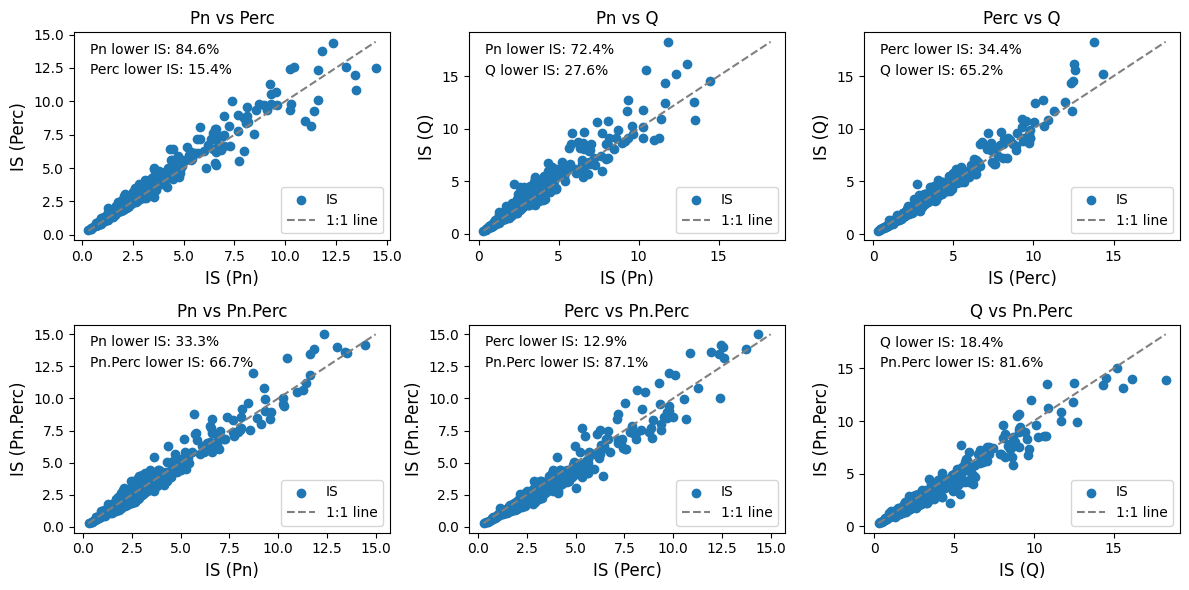

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Convert lists to numpy arrays ---
IS_Pn = np.array(IS_Pn)
IS_Perc = np.array(IS_Perc)
IS_Q = np.array(IS_Q)
IS_PnPerc = np.array(IS_PnPerc)

assert len(IS_Pn) == len(IS_Perc) == len(IS_Q) == len(IS_PnPerc)

pairs = [
    (IS_Pn, IS_Perc, "Pn", "Perc"),
    (IS_Pn, IS_Q, "Pn", "Q"),
    (IS_Perc, IS_Q, "Perc", "Q"),
    (IS_Pn, IS_PnPerc, "Pn", "Pn.Perc"),
    (IS_Perc, IS_PnPerc, "Perc", "Pn.Perc"),
    (IS_Q, IS_PnPerc, "Q", "Pn.Perc"),
]

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

# Define font sizes
label_fontsize = 12
title_fontsize = 12
annotation_fontsize = 10
legend_fontsize = 10

n_basins = len(IS_Pn)

for ax, (x, y, name_x, name_y) in zip(axes, pairs):

    # Scatter
    ax.scatter(x, y, label="IS")

    # 1:1 line
    min_val = min(np.min(x), np.min(y))
    max_val = max(np.max(x), np.max(y))
    ax.plot([min_val, max_val], [min_val, max_val],
            linestyle='--', color='gray', label="1:1 line")

    # Count wins (lower IS = better)
    x_wins = np.sum(x < y)
    y_wins = np.sum(y < x)
    ties = np.sum(x == y)

    # Convert to percentages
    x_pct = 100 * x_wins / n_basins
    y_pct = 100 * y_wins / n_basins
    ties_pct = 100 * ties / n_basins

    # Axis labels
    ax.set_xlabel(f"IS ({name_x})", fontsize=label_fontsize)
    ax.set_ylabel(f"IS ({name_y})", fontsize=label_fontsize)

    # Title
    ax.set_title(f"{name_x} vs {name_y}", fontsize=title_fontsize)

    # Annotation (panel statistics in %)
    ax.text(0.05, 0.95,
        f"{name_x} lower IS: {x_pct:.1f}%\n"
        f"{name_y} lower IS: {y_pct:.1f}%",
        transform=ax.transAxes,
        verticalalignment='top',
        linespacing=1.6,
        fontsize=annotation_fontsize)

    ax.legend(fontsize=legend_fontsize)

plt.tight_layout()

# Save
plt.savefig("scater_IS.jpeg", format='jpeg', dpi=700)
#files.download("scater_IS.jpeg")

plt.show()

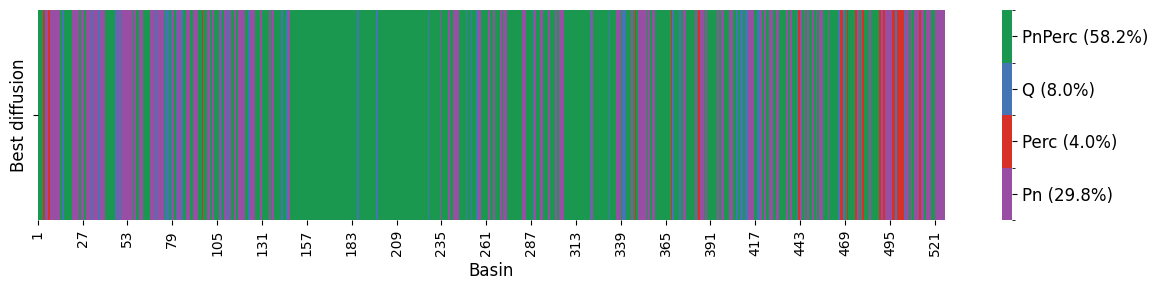

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

# Example dataframe
df = pd.DataFrame({
     "Pn": IS_Pn,
     "Perc": IS_Perc,
     "Q": IS_Q,
     "PnPerc": IS_PnPerc
 })

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

# Example data (replace with your actual lists)
# IS_Pn, IS_Perc, IS_Q, IS_PnPerc must be defined
df = pd.DataFrame({
    "Pn": IS_Pn,
    "Perc": IS_Perc,
    "Q": IS_Q,
    "PnPerc": IS_PnPerc
})

# Map methods to numbers
method_map = {"Pn": 0, "Perc": 1, "Q": 2, "PnPerc": 3}

# Find the best method per basin (min IS)
df["Best_method"] = df.idxmin(axis=1)
df["Best_num"] = df["Best_method"].map(method_map)

# Count and percentage
counts = df["Best_method"].value_counts().reindex(method_map.keys(), fill_value=0)
percentages = 100 * counts / len(df)

# Saturated color palette
colors = ["#984ea3", "#d73027", "#4575b4",  "#1a9850"]  # purple, red, blue, green
cmap = ListedColormap(colors)
bounds = [0, 1, 2, 3, 4]
norm = BoundaryNorm(bounds, cmap.N)

# Heatmap
fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(
    [df["Best_num"].values],       # keep one row for basins
    cmap=cmap,
    norm=norm,
    cbar_kws={'ticks':[0.5,1.5,2.5,3.5]},
    ax=ax
)

# Colorbar labels with percentage
cbar = ax.collections[0].colorbar
cbar.set_ticklabels([f"{method} ({percentages[method]:.1f}%)" for method in method_map.keys()])
cbar.ax.tick_params(labelsize=12)

# Axes
ax.set_yticklabels(["Best diffusion"], fontsize=12)
num_basins = len(df)
step = max(1, num_basins // 20)
ax.set_xticks(range(0, num_basins, step))
ax.set_xticklabels(range(1, num_basins+1, step), fontsize=10)
ax.set_xlabel("Basin", fontsize=12)

plt.tight_layout()
plt.savefig("scatter_IS2.jpeg", format='jpeg', dpi=700)
plt.show()

Pourcentage global par rang (somme des diffusions = 100% pour chaque rang) :
            1      2      3      4
Pn      29.85  41.56  17.49  11.05
Perc     3.99   9.11  32.89  54.10
Q        7.98  24.86  37.83  29.33
PnPerc  58.17  24.48  11.79   5.52
Somme par rang :
1     99.99
2    100.01
3    100.00
4    100.00
dtype: float64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

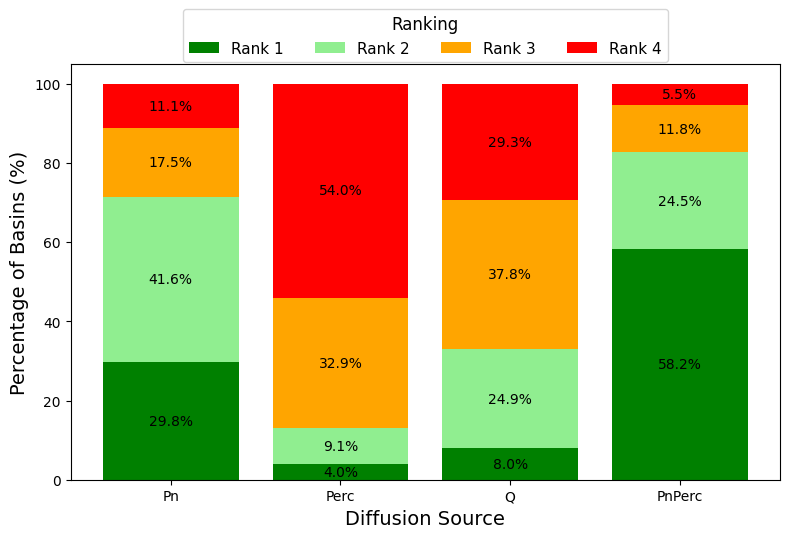

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Dataframe
# ----------------------------
df = pd.DataFrame({
    "Pn": IS_Pn,
    "Perc": IS_Perc,
    "Q": IS_Q,
    "PnPerc": IS_PnPerc
})

# ----------------------------
# Ranking per basin (1 = best)
# ----------------------------
df_rank = df.rank(axis=1, method="min", ascending=True).astype(int)

# ----------------------------
# Count occurrences per diffusion and per rank
# ----------------------------
rank_counts = pd.DataFrame(index=df.columns, columns=[1,2,3,4])
for col in df.columns:
    counts = df_rank[col].value_counts()
    for r in [1,2,3,4]:
        rank_counts.loc[col, r] = counts.get(r, 0)
rank_counts = rank_counts.astype(int)

# ----------------------------
# 1️⃣ Percentage for stacked barplot (per diffusion)
# ----------------------------
rank_percent_line = rank_counts.div(rank_counts.sum(axis=1), axis=0) * 100

# Rounding for display and correction so each bar = 100%
rank_percent_line_display = rank_percent_line.round(1)
for idx in rank_percent_line_display.index:
    diff = 100 - rank_percent_line_display.loc[idx].sum()
    rank_percent_line_display.loc[idx, rank_percent_line_display.columns[-1]] += diff

# ----------------------------
# 2️⃣ Global percentage per rank (sum of diffusions = 100% for each rank)
# ----------------------------
rank_percent_rank = rank_counts.div(rank_counts.sum(axis=0), axis=1) * 100  # column-wise division
# Keep 2 decimals for exact computation
rank_percent_rank = rank_percent_rank.round(2)

print("Global percentage per rank (sum of diffusions = 100% for each rank):")
print(rank_percent_rank)
print("Sum per rank:")
print(rank_percent_rank.sum())  # should be exactly 100 for each rank

# ----------------------------
# 3️⃣ Stacked Barplot
# ----------------------------
fig, ax = plt.subplots(figsize=(8,5.5))
colors = ["green", "lightgreen", "orange", "red"]
bottom = np.zeros(len(rank_percent_line_display))

for i, rank in enumerate([1,2,3,4]):
    values = rank_percent_line_display[rank].values
    ax.bar(rank_percent_line_display.index,
           values,
           bottom=bottom,
           color=colors[i],
           label=f"Rank {rank}")

    # Add labels
    for j, v in enumerate(values):
        if v > 3:  # avoid displaying if too small
            ax.text(j,
                    bottom[j] + v/2,
                    f"{v:.1f}%",
                    ha='center',
                    va='center',
                    fontsize=10,
                    color='black')

    bottom += values

ax.set_ylabel("Percentage of Basins (%)", fontsize=14)
ax.set_xlabel("Diffusion Source", fontsize=14)
ax.legend(title="Ranking",
          loc="upper center",
          bbox_to_anchor=(0.5,1.15),
          ncol=4,
          fontsize=11,
          title_fontsize=12)

plt.tight_layout()
plt.savefig("IS_Perf.jpeg", format='jpeg', dpi=700)
#files.download("IS_Perf.jpeg")
plt.show()